# RBC Full-On Output — Single Model Evaluation

Evaluate energy, CO2, and temperature performance for one EnergyPlus output.

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Column mapping & constants ───────────────────────────────────────────────

COLUMN_NAMES = [
    'Time',
    'Outdoor_Tdb_C',
    'Outdoor_Twb_C',
    'Space1_occupants', 'Space2_occupants', 'Space3_occupants',
    'Space4_occupants', 'Space5_occupants',
    'lights-1', 'lights-2', 'lights-3', 'lights-4', 'lights-5',
    'equip-1', 'equip-2', 'equip-3', 'equip-4', 'equip-5',
    'Plenum1_T_C', 'Plenum1_RH_%',
    'Space1_T_C', 'Space1_RH_%',
    'Space2_T_C', 'Space2_RH_%',
    'Space3_T_C', 'Space3_RH_%',
    'Space4_T_C', 'Space4_RH_%',
    'Space5_T_C', 'Space5_RH_%',
    'Plenum_CO2_ppm', 'Plenum_CO2_pred', 'Plenum_CO2_setpoint_ppm', 'Plenum_CO2_internal_gain',
    'Space1_CO2_ppm', 'Space1_CO2_pred', 'Space1_CO2_setpoint_ppm', 'Space1_CO2_internal_gain',
    'Space2_CO2_ppm', 'Space2_CO2_pred', 'Space2_CO2_setpoint_ppm', 'Space2_CO2_internal_gain',
    'Space3_CO2_ppm', 'Space3_CO2_pred', 'Space3_CO2_setpoint_ppm', 'Space3_CO2_internal_gain',
    'Space4_CO2_ppm', 'Space4_CO2_pred', 'Space4_CO2_setpoint_ppm', 'Space4_CO2_internal_gain',
    'Space5_CO2_ppm', 'Space5_CO2_pred', 'Space5_CO2_setpoint_ppm', 'Space5_CO2_internal_gain',
    'doas_fan',
    'fcu_1', 'fcu_2', 'fcu_3', 'fcu_4', 'fcu_5',
    'hex', 'chiller', 'tower', 'boiler',
    'coldw_pump', 'condw_pump', 'hotw_pump',
    'Node2_T_C', 'Node2_Mdot_kg/s', 'Node2_W_Ratio',
    'Node2_SP_T_C', 'Node2_CO2_ppm', 'Node1_T_C',
    'Gas_Facility_E_J', 'Elec_Facility_E_J', 'Elec_HVAC_E_J',
    'CoolingCoils:EnergyTransfer', 'HeatingCoils:EnergyTransfer',
    'ElectricityNet:Facility',
    'General:Cooling:EnergyTransfer', 'Cooling:EnergyTransfer',
]

ELEC_PRICE = 0.11   # €/kWh
GAS_PRICE  = 0.06   # €/kWh
J_TO_KWH   = 1 / 3.6e6

In [267]:
## Utility functions

In [268]:
def load_eplusout(csv_path: str) -> pd.DataFrame:
    """Load an EnergyPlus CSV, fix the 24:00 timestamp, rename columns."""
    df = pd.read_csv(csv_path)
    df['Date/Time'] = df['Date/Time'].str.strip()

    mask_24 = df['Date/Time'].str.contains('24:00:00')
    df.loc[mask_24, 'Date/Time'] = (
        df.loc[mask_24, 'Date/Time'].str.replace('24:00:00', '00:00:00')
    )
    df['Date/Time'] = '2024/' + df['Date/Time']
    df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%Y/%m/%d %H:%M:%S')
    df.loc[mask_24, 'Date/Time'] += pd.Timedelta(days=1)

    df.columns = COLUMN_NAMES
    return df

In [269]:
# ── Energy functions ─────────────────────────────────────────────────────────

def compute_annual_energy(df: pd.DataFrame) -> pd.Series:
    cols = ['Gas_Facility_E_J', 'Elec_Facility_E_J', 'Elec_HVAC_E_J']
    return df[cols].sum() * J_TO_KWH


def compute_monthly_energy(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Time'] = pd.to_datetime(df['Time'])
    monthly = df.groupby(df['Time'].dt.to_period('M')).agg(
        elec_fac_kWh=('Elec_Facility_E_J', lambda x: x.sum() * J_TO_KWH),
        elec_hvac_kWh=('Elec_HVAC_E_J', lambda x: x.sum() * J_TO_KWH),
        gas_kWh=('Gas_Facility_E_J', lambda x: x.sum() * J_TO_KWH),
    )
    monthly['elec_fac_cost_eur'] = monthly['elec_fac_kWh'] * ELEC_PRICE
    monthly['elec_hvac_cost_eur'] = monthly['elec_hvac_kWh'] * ELEC_PRICE
    monthly['gas_cost_eur'] = monthly['gas_kWh'] * GAS_PRICE
    monthly['total_cost_eur'] = monthly['elec_fac_cost_eur'] + monthly['gas_cost_eur']
    return monthly


def compute_hvac_enduse_energy(df: pd.DataFrame) -> pd.Series:
    cols = ['doas_fan', 'fcu_1', 'fcu_2', 'fcu_3', 'fcu_4', 'fcu_5']
    return df[cols].sum() * J_TO_KWH

In [270]:
# ── Temperature functions ────────────────────────────────────────────────────

def compute_temperature_limits(df, t_out_col='Outdoor_Tdb_C'):
    t_mean = df[t_out_col].rolling(24, min_periods=24).mean()
    t = pd.to_numeric(t_mean, errors='coerce').to_numpy(dtype=float)

    lower_S1 = np.where(t <= 0, 20.5, np.where(t <= 20, 20.5 + 0.075 * t, 22.0))
    upper_S1 = np.where(t <= 0, 22.0, np.where(t <= 15, 22.5 + 0.166 * t, 25.0))
    lower_S2 = np.where(t <= 0, 20.5, np.where(t <= 20, 20.5 + 0.025 * t, 21.0))
    upper_S2 = np.where(t <= 0, 23.0, np.where(t <= 15, 23.0 + 0.20  * t, 26.0))
    lower_S3 = np.full_like(t, 20.0)
    upper_S3 = np.where(t <= 10, 25.0, 27.0)

    return lower_S1, upper_S1, lower_S2, upper_S2, lower_S3, upper_S3


def classify_temperature(t_in, lower_S1, upper_S1, lower_S2, upper_S2, lower_S3, upper_S3):
    cond_S1 = (t_in >= lower_S1) & (t_in <= upper_S1)
    cond_S2 = (t_in >= lower_S2) & (t_in <= upper_S2)
    cond_S3 = (t_in >= lower_S3) & (t_in <= upper_S3)
    return np.select([cond_S1, cond_S2, cond_S3], ['S1', 'S2', 'S3'], default='Out of class')


def analyze_temperature(df: pd.DataFrame) -> pd.DataFrame:
    limits = compute_temperature_limits(df)
    rows = []
    for i in range(1, 6):
        col = f'Space{i}_T_C'
        t_in = pd.to_numeric(df[col], errors='coerce')
        classes = classify_temperature(t_in, *limits)
        counts = pd.Series(classes).value_counts()

        s1 = counts.get('S1', 0)
        s2 = counts.get('S2', 0)
        s3 = counts.get('S3', 0)
        out = counts.get('Out of class', 0)
        total = s1 + s2 + s3 + out

        rows.append({
            'space': col,
            'avg_T_C': t_in.mean(),
            'hours_below_20C': (t_in < 20.0).sum(),
            'S1_h': s1, 'S2_h': s2, 'S3_h': s3, 'out_h': out,
            'S1_%': 100 * s1 / total if total else 0,
            'S2_cum_%': 100 * (s1 + s2) / total if total else 0,
            'S3_cum_%': 100 * (s1 + s2 + s3) / total if total else 0,
        })
    return pd.DataFrame(rows).set_index('space')

In [271]:
# ── CO2 functions ────────────────────────────────────────────────────────────

CO2_THRESHOLDS = [770, 970, 1220]
ZONE_CO2_COLS  = [f'Space{i}_CO2_ppm' for i in range(1, 6)]
CLASS_THRESHOLD = 0.90  # 90% of hours must be below limit for classification


def compute_co2_mean(df: pd.DataFrame) -> pd.Series:
    return df[ZONE_CO2_COLS].mean()


def compute_co2_exceedances(df: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        {f'>{t} ppm': (df[ZONE_CO2_COLS] > t).sum() for t in CO2_THRESHOLDS},
        axis=1,
    )


def co2_class_90pct(co2_series: pd.Series) -> str:
    """Classify CO2 using the 90% rule (≥90% of hours below threshold)."""
    total = len(co2_series)
    if total == 0:
        return 'No data'
    if (co2_series <= 770).sum() / total >= CLASS_THRESHOLD:
        return 'S1'
    if (co2_series <= 970).sum() / total >= CLASS_THRESHOLD:
        return 'S2'
    if (co2_series <= 1220).sum() / total >= CLASS_THRESHOLD:
        return 'S3'
    return 'Out of class'


def compute_co2_classification(df: pd.DataFrame) -> pd.DataFrame:
    total = len(df)
    rows = []
    for col in ZONE_CO2_COLS:
        co2 = df[col]
        rows.append({
            'space': col,
            'max_ppm': co2.max(),
            'mean_ppm': co2.mean(),
            'pct_below_770': 100 * (co2 <= 770).sum() / total if total else 0,
            'pct_below_970': 100 * (co2 <= 970).sum() / total if total else 0,
            'pct_below_1220': 100 * (co2 <= 1220).sum() / total if total else 0,
            'class': co2_class_90pct(co2),
        })
    return pd.DataFrame(rows).set_index('space')

In [272]:
# ── Penalty cost functions ────────────────────────────────────────────────────

# CO2 penalty prices (€/h per space)
CO2_P1 = 2    # €/h — above S1 (770 ppm) but ≤ S2 (970 ppm)
CO2_P2 = 10   # €/h — above S2 (970 ppm) but ≤ S3 (1220 ppm)
CO2_P3 = 50   # €/h — above S3 (1220 ppm)

# Temperature penalty prices (€/h per space, for hours outside class band)
TEMP_P1 = 1    # €/h — outside S1 but inside S2
TEMP_P2 = 5    # €/h — outside S2 but inside S3
TEMP_P3 = 25   # €/h — outside S3


def compute_co2_penalty(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in ZONE_CO2_COLS:
        co2 = df[col]
        h_s1_s2 = ((co2 > 770) & (co2 <= 970)).sum()
        h_s2_s3 = ((co2 > 970) & (co2 <= 1220)).sum()
        h_above  = (co2 > 1220).sum()
        cost = CO2_P1 * h_s1_s2 + CO2_P2 * h_s2_s3 + CO2_P3 * h_above
        rows.append({
            'space': col.replace('_CO2_ppm', ''),
            'h_above_S1': h_s1_s2, 'h_above_S2': h_s2_s3,
            'h_above_S3': h_above, 'penalty_eur': cost,
        })
    return pd.DataFrame(rows).set_index('space')


def compute_temperature_penalty(df: pd.DataFrame) -> pd.DataFrame:
    limits = compute_temperature_limits(df)
    lower_S1, upper_S1, lower_S2, upper_S2, lower_S3, upper_S3 = limits

    rows = []
    for i in range(1, 6):
        col = f'Space{i}_T_C'
        t_in = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)
        total = len(t_in)

        in_s1 = (t_in >= lower_S1) & (t_in <= upper_S1)
        in_s2 = (t_in >= lower_S2) & (t_in <= upper_S2)
        in_s3 = (t_in >= lower_S3) & (t_in <= upper_S3)

        h_s1_only = (~in_s1 & in_s2).sum()
        h_s2_only = (~in_s2 & in_s3).sum()
        h_out     = (~in_s3).sum()

        penalty = TEMP_P1 * h_s1_only + TEMP_P2 * h_s2_only + TEMP_P3 * h_out

        pct_s1 = 100 * in_s1.sum() / total if total else 0
        pct_s2 = 100 * in_s2.sum() / total if total else 0
        pct_s3 = 100 * in_s3.sum() / total if total else 0
        pct_req = CLASS_THRESHOLD * 100
        if pct_s1 >= pct_req:
            achieved = 'S1'
        elif pct_s2 >= pct_req:
            achieved = 'S2'
        elif pct_s3 >= pct_req:
            achieved = 'S3'
        else:
            achieved = 'Out of class'

        rows.append({
            'space': f'Space{i}',
            'achieved_class': achieved,
            'h_outside_S1': h_s1_only,
            'h_outside_S2': h_s2_only,
            'h_outside_S3': h_out,
            'S1_%': pct_s1,
            'penalty_eur': penalty,
        })
    return pd.DataFrame(rows).set_index('space')


def compute_total_cost(df: pd.DataFrame) -> dict:
    monthly = compute_monthly_energy(df)
    energy_cost = monthly['total_cost_eur'].sum()
    co2_cost = compute_co2_penalty(df)['penalty_eur'].sum()
    temp_cost = compute_temperature_penalty(df)['penalty_eur'].sum()
    return {
        'energy_cost_eur': energy_cost,
        'co2_penalty_eur': co2_cost,
        'temp_penalty_eur': temp_cost,
        'total_cost_eur': energy_cost + co2_cost + temp_cost,
    }

In [273]:
## Load model

CSV_PATH = 'eplus_out/eplusout.csv'
MODEL_NAME = 'RBC Full-On'

df = load_eplusout(CSV_PATH)
print(f'Loaded {MODEL_NAME}: {len(df)} rows, {df["Time"].min()} → {df["Time"].max()}')

Loaded RBC Full-On: 8760 rows, 2024-01-01 01:00:00 → 2025-01-01 00:00:00


## Energy

In [274]:
# ── Annual energy summary ────────────────────────────────────────────────────

annual = compute_annual_energy(df)
print(f'Annual energy use (kWh) — {MODEL_NAME}:')
print(annual.round(2))
print()
print(f'Electricity (Facility) : {annual["Elec_Facility_E_J"]:.2f} kWh')
print(f'Electricity (HVAC)     : {annual["Elec_HVAC_E_J"]:.2f} kWh')
print(f'Gas (Facility)         : {annual["Gas_Facility_E_J"]:.2f} kWh')

Annual energy use (kWh) — RBC Full-On:
Gas_Facility_E_J     51185.88
Elec_Facility_E_J    44286.31
Elec_HVAC_E_J         4359.15
dtype: float64

Electricity (Facility) : 44286.31 kWh
Electricity (HVAC)     : 4359.15 kWh
Gas (Facility)         : 51185.88 kWh


In [275]:
# ── Monthly energy breakdown ─────────────────────────────────────────────────

monthly = compute_monthly_energy(df)
print(monthly.round(2))
print()
print(f'Total annual cost: {monthly["total_cost_eur"].sum():.2f} €')

         elec_fac_kWh  elec_hvac_kWh  gas_kWh  elec_fac_cost_eur  \
Time                                                               
2024-01       3635.77         396.91  6695.72             399.93   
2024-02       3350.28         352.67  5248.93             368.53   
2024-03       3908.89         396.13  4947.71             429.98   
2024-04       3488.97         344.24  3889.84             383.79   
2024-05       3970.17         365.12  2850.57             436.72   
2024-06       3803.20         347.02  2573.91             418.35   
2024-07       3823.81         334.13  2584.45             420.62   
2024-08       4061.97         356.17  2766.31             446.82   
2024-09       3530.38         339.06  3471.71             388.34   
2024-10       3615.23         369.01  4464.44             397.68   
2024-11       3597.49         375.96  5293.63             395.72   
2024-12       3499.26         382.52  6388.86             384.92   
2025-01          0.88           0.22     9.80   

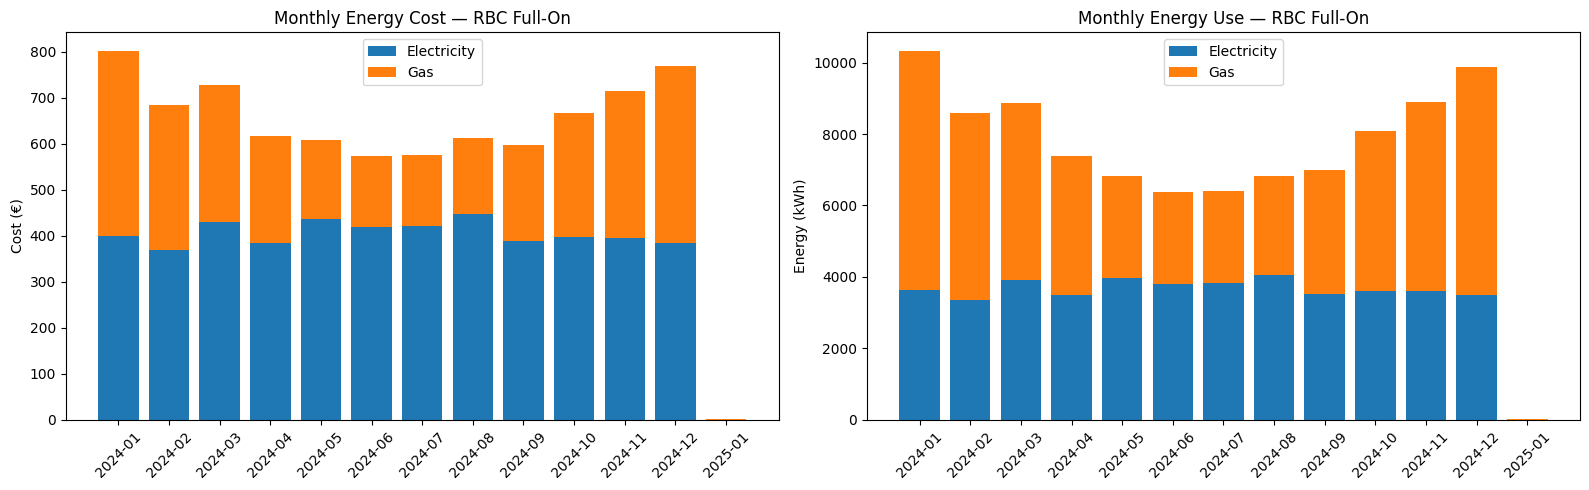

In [276]:
# ── Monthly cost plot ────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(monthly.index.astype(str), monthly['elec_fac_cost_eur'], label='Electricity')
ax.bar(monthly.index.astype(str), monthly['gas_cost_eur'],
       bottom=monthly['elec_fac_cost_eur'], label='Gas')
ax.set_ylabel('Cost (€)')
ax.set_title(f'Monthly Energy Cost — {MODEL_NAME}')
ax.legend()
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.bar(monthly.index.astype(str), monthly['elec_fac_kWh'], label='Electricity')
ax.bar(monthly.index.astype(str), monthly['gas_kWh'],
       bottom=monthly['elec_fac_kWh'], label='Gas')
ax.set_ylabel('Energy (kWh)')
ax.set_title(f'Monthly Energy Use — {MODEL_NAME}')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [277]:
# ── HVAC end-use breakdown ───────────────────────────────────────────────────

hvac = compute_hvac_enduse_energy(df)
print(f'HVAC end-use breakdown (kWh) — {MODEL_NAME}:')
print(hvac.round(2))
print(f'Total HVAC end-uses: {hvac.sum():.2f} kWh')
print(f'Elec_HVAC_E_J total: {df["Elec_HVAC_E_J"].sum() * J_TO_KWH:.2f} kWh')

HVAC end-use breakdown (kWh) — RBC Full-On:
doas_fan    3598.67
fcu_1        190.47
fcu_2         87.94
fcu_3        173.67
fcu_4         82.43
fcu_5        225.97
dtype: float64
Total HVAC end-uses: 4359.15 kWh
Elec_HVAC_E_J total: 4359.15 kWh


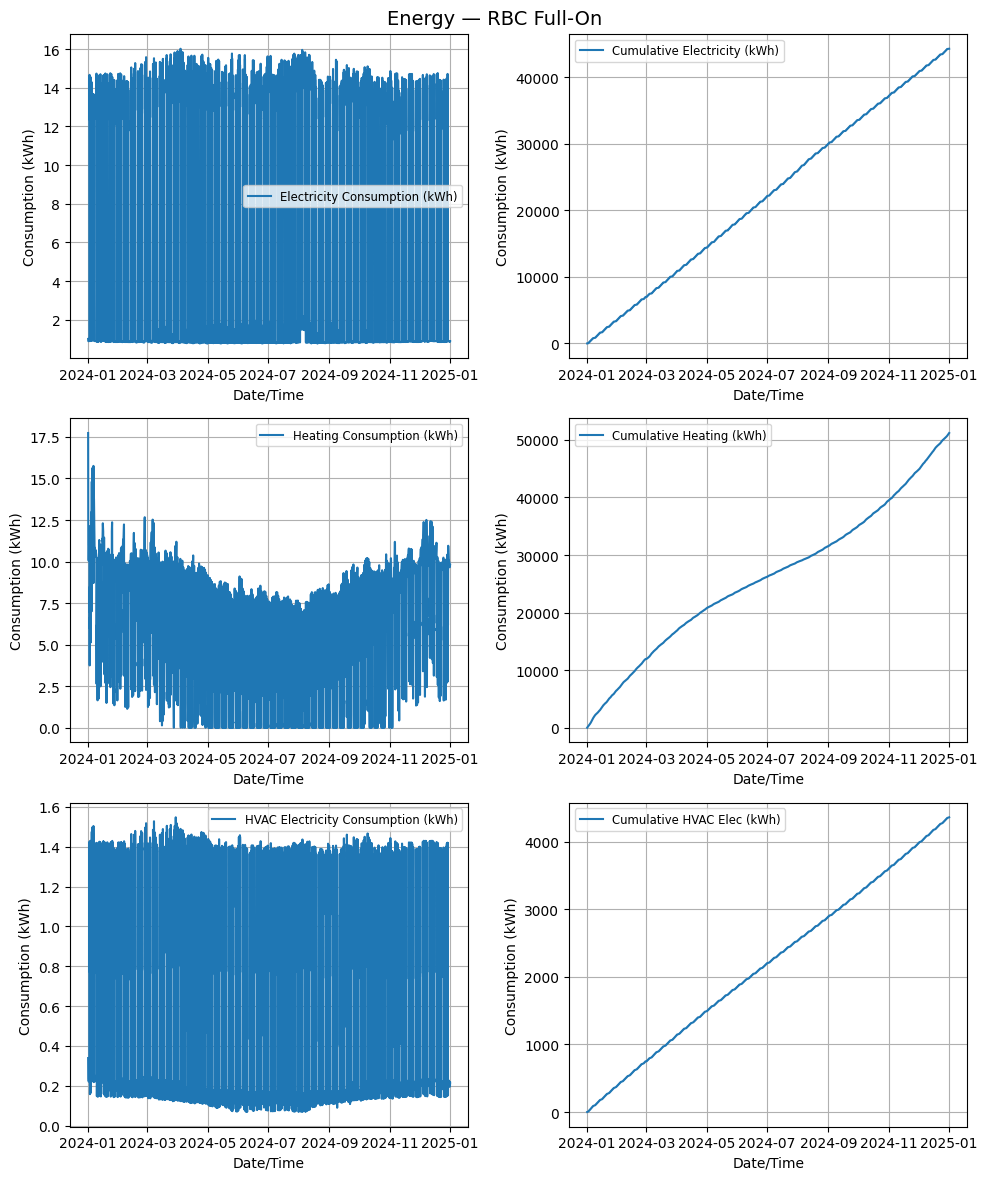

In [278]:
# ── Cumulative energy plots ──────────────────────────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes[0, 0].plot(df['Time'], df['Elec_Facility_E_J'] / 3.6e6, label='Electricity Consumption (kWh)')
axes[1, 0].plot(df['Time'], df['Gas_Facility_E_J'] / 3.6e6, label='Heating Consumption (kWh)')
axes[2, 0].plot(df['Time'], df['Elec_HVAC_E_J'] / 3.6e6, label='HVAC Electricity Consumption (kWh)')

axes[0, 1].plot(df['Time'], df['Elec_Facility_E_J'].cumsum() / 3.6e6, label='Cumulative Electricity (kWh)')
axes[1, 1].plot(df['Time'], df['Gas_Facility_E_J'].cumsum() / 3.6e6, label='Cumulative Heating (kWh)')
axes[2, 1].plot(df['Time'], df['Elec_HVAC_E_J'].cumsum() / 3.6e6, label='Cumulative HVAC Elec (kWh)')

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('Date/Time')
        ax.set_ylabel('Consumption (kWh)')
        ax.legend(fontsize='small')
        ax.grid(True)

plt.suptitle(f'Energy — {MODEL_NAME}', fontsize=14)
plt.tight_layout()
plt.show()

## CO2

In [279]:
# ── CO2 summary ──────────────────────────────────────────────────────────────

print(f'Average CO2 by space (ppm) — {MODEL_NAME}:')
print(compute_co2_mean(df).round(2))
print()

print(f'Hours above thresholds — {MODEL_NAME}:')
exc = compute_co2_exceedances(df)
print(exc)
print(f'Total exceedances: {exc.to_numpy().sum()}')
print()

print(f'CO2 classification — {MODEL_NAME}:')
print(compute_co2_classification(df))

Average CO2 by space (ppm) — RBC Full-On:
Space1_CO2_ppm    553.32
Space2_CO2_ppm    525.24
Space3_CO2_ppm    554.37
Space4_CO2_ppm    553.80
Space5_CO2_ppm    552.49
dtype: float64

Hours above thresholds — RBC Full-On:
                >770 ppm  >970 ppm  >1220 ppm
Space1_CO2_ppm        53         0          0
Space2_CO2_ppm         0         0          0
Space3_CO2_ppm        61         0          0
Space4_CO2_ppm        64         0          0
Space5_CO2_ppm        68         0          0
Total exceedances: 246

CO2 classification — RBC Full-On:
                   max_ppm    mean_ppm  pct_below_770  pct_below_970  \
space                                                                  
Space1_CO2_ppm  793.480749  553.316372      99.394977          100.0   
Space2_CO2_ppm  718.224842  525.237066     100.000000          100.0   
Space3_CO2_ppm  792.818798  554.366877      99.303653          100.0   
Space4_CO2_ppm  793.446384  553.800034      99.269406          100.0   
Space5_CO2_pp

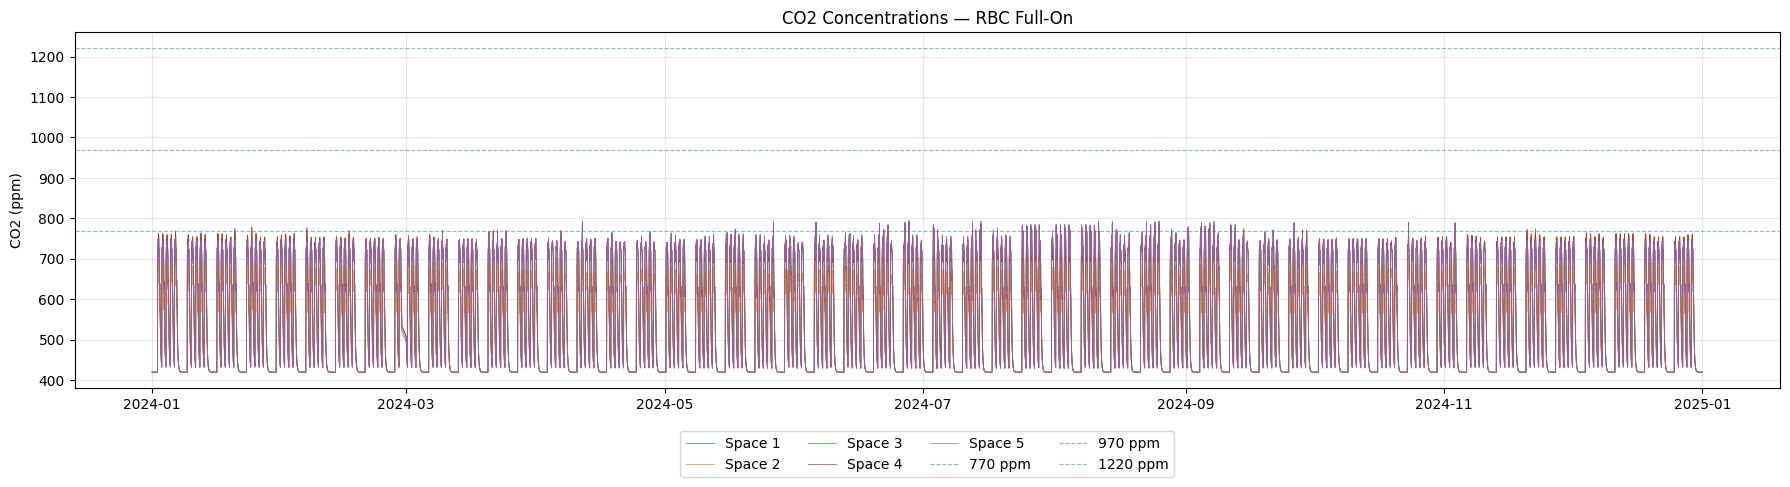

In [280]:
# ── CO2 time-series plot ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 5))
x = pd.to_datetime(df['Time'])
for i in range(1, 6):
    ax.plot(x, df[f'Space{i}_CO2_ppm'], linewidth=0.6, alpha=0.8, label=f'Space {i}')

for t in CO2_THRESHOLDS:
    ax.axhline(t, linestyle='--', linewidth=0.8, alpha=0.5, label=f'{t} ppm')

ax.set_ylabel('CO2 (ppm)')
ax.set_title(f'CO2 Concentrations — {MODEL_NAME}')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

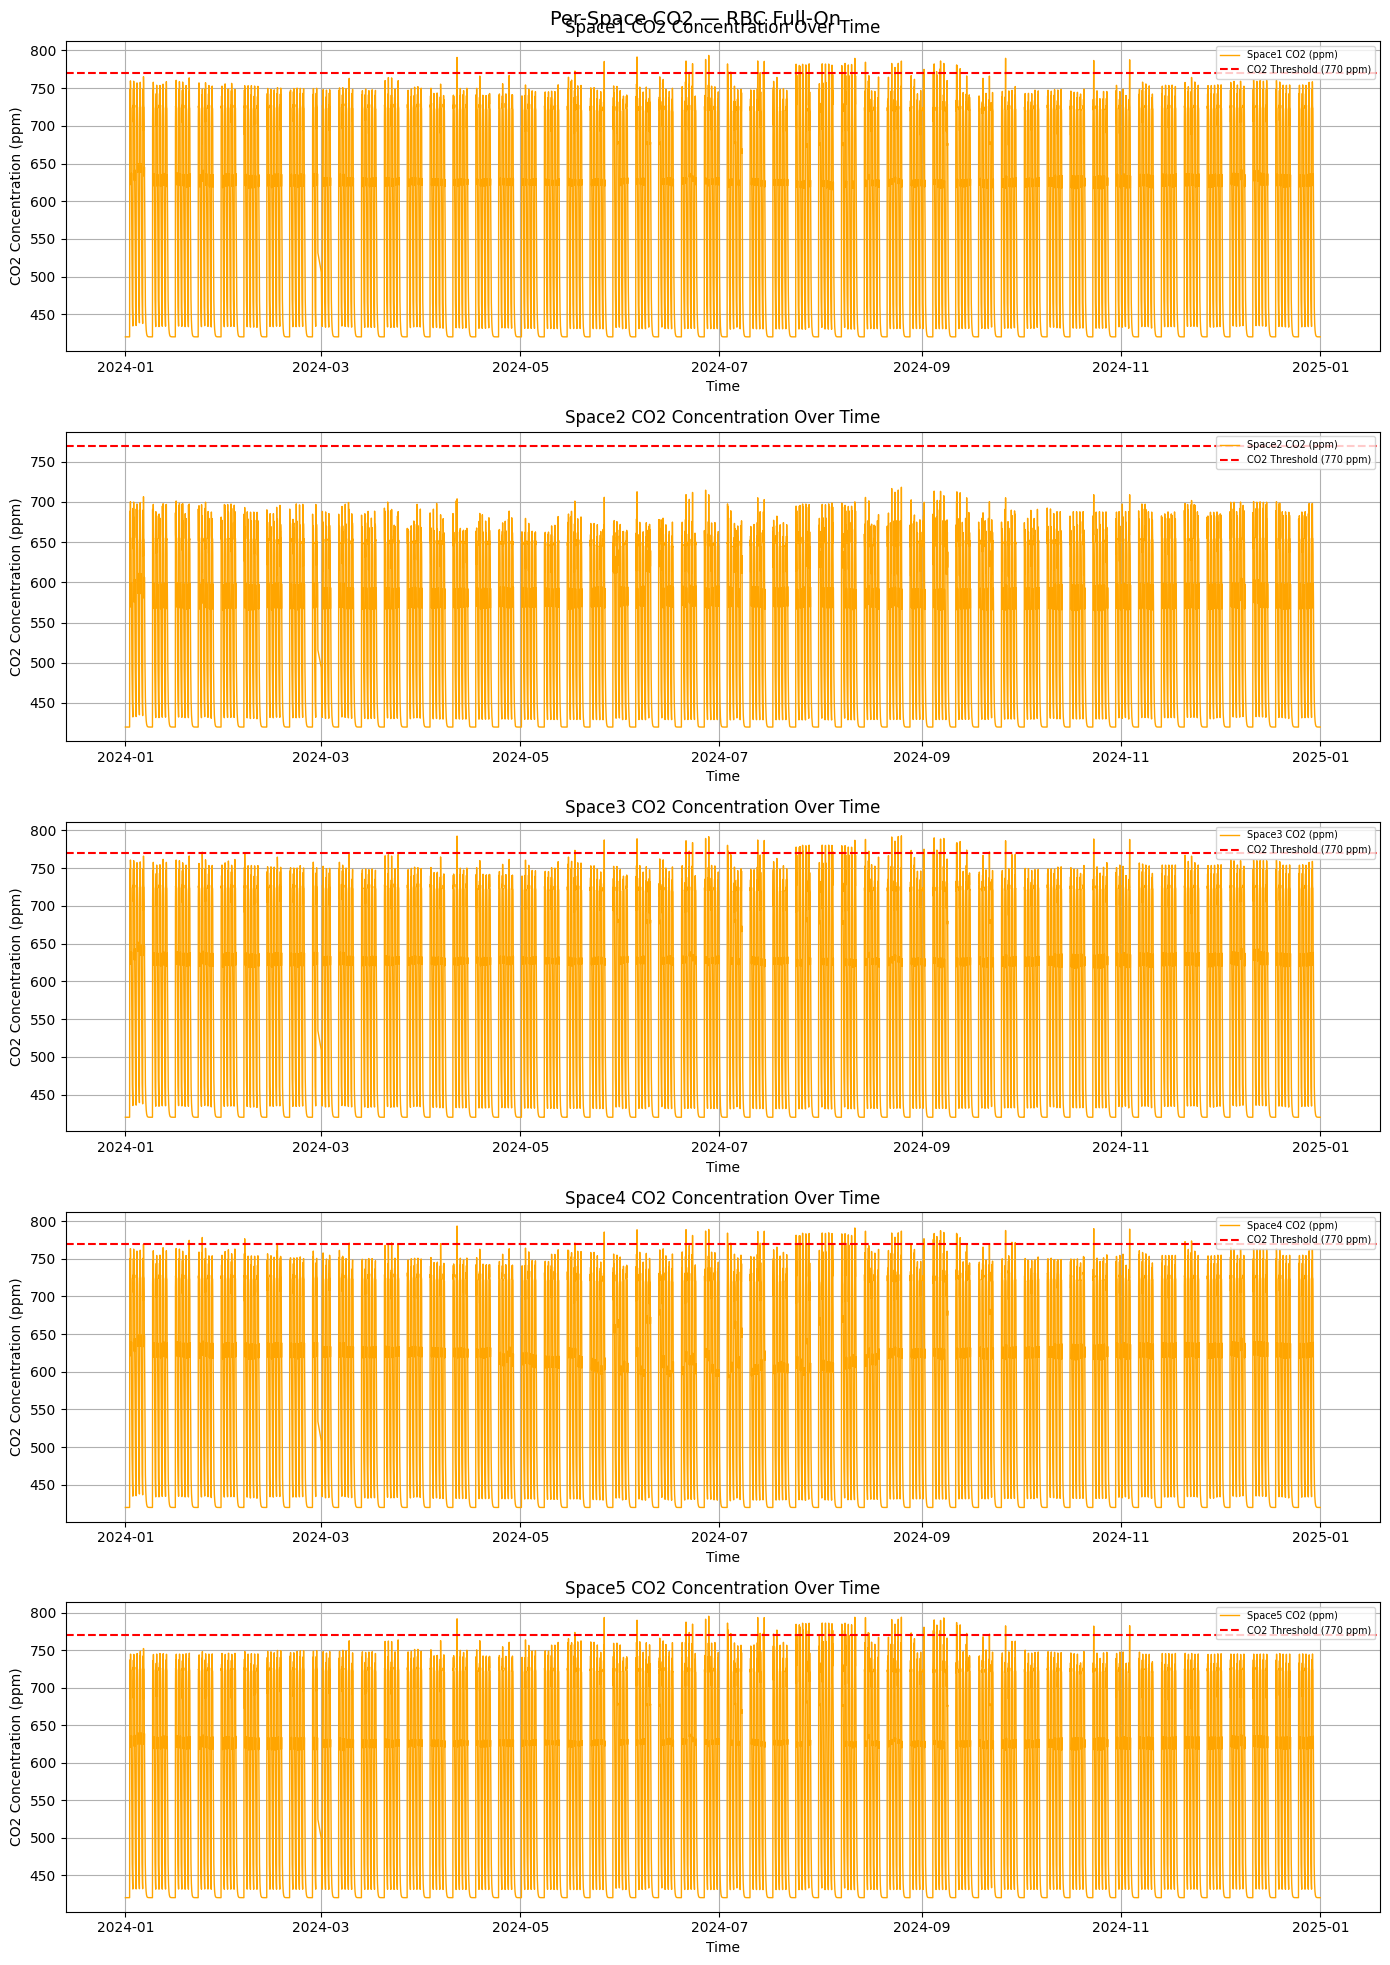

In [281]:
# ── CO2 per-space subplots ───────────────────────────────────────────────────

fig, axes = plt.subplots(5, 1, figsize=(14, 20))
for i in range(5):
    axes[i].plot(df['Time'], df[f'Space{i+1}_CO2_ppm'], label=f'Space{i+1} CO2 (ppm)', color='orange', linewidth=1.0)
    axes[i].axhline(y=770, color='red', linestyle='--', label='CO2 Threshold (770 ppm)')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('CO2 Concentration (ppm)')
    axes[i].set_title(f'Space{i+1} CO2 Concentration Over Time')
    axes[i].legend(fontsize='x-small')
    axes[i].grid(True)
plt.suptitle(f'Per-Space CO2 — {MODEL_NAME}', fontsize=14)
plt.tight_layout()
plt.show()

## Temperature

In [282]:
# ── Temperature class analysis ───────────────────────────────────────────────

temp_summary = analyze_temperature(df)
print(f'Temperature analysis — {MODEL_NAME}:')
print(temp_summary.round(2))

Temperature analysis — RBC Full-On:
            avg_T_C  hours_below_20C  S1_h  S2_h  S3_h  out_h   S1_%  \
space                                                                  
Space1_T_C    22.02                0  8719    40     1      0  99.53   
Space2_T_C    22.04                0  8730    29     1      0  99.66   
Space3_T_C    22.00                0  8732    27     1      0  99.68   
Space4_T_C    22.05                0  8719    40     1      0  99.53   
Space5_T_C    22.02                0  8716    43     1      0  99.50   

            S2_cum_%  S3_cum_%  
space                           
Space1_T_C     99.99     100.0  
Space2_T_C     99.99     100.0  
Space3_T_C     99.99     100.0  
Space4_T_C     99.99     100.0  
Space5_T_C     99.99     100.0  


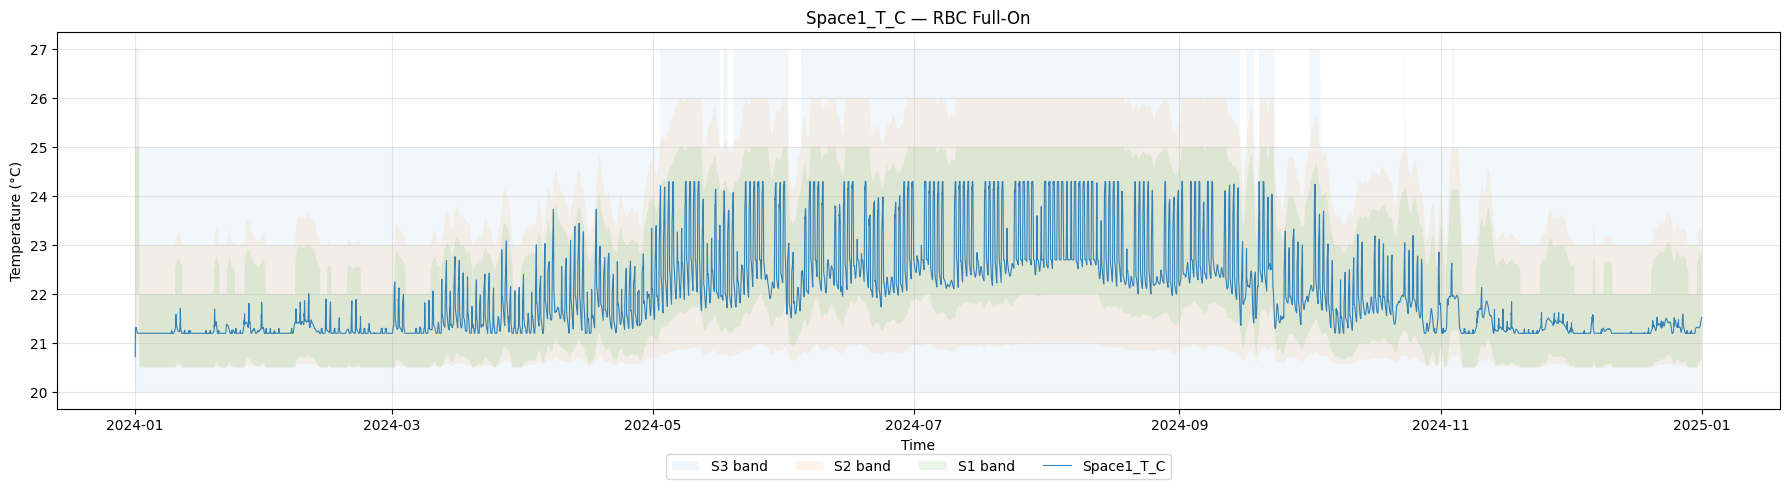

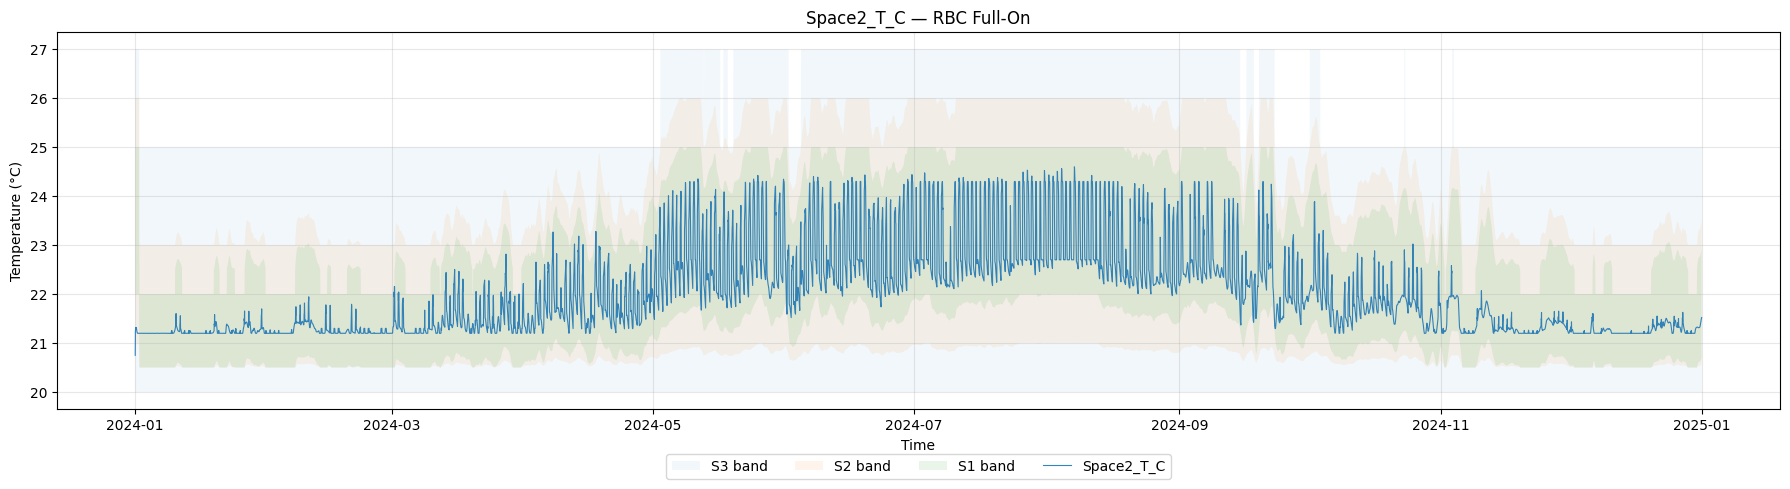

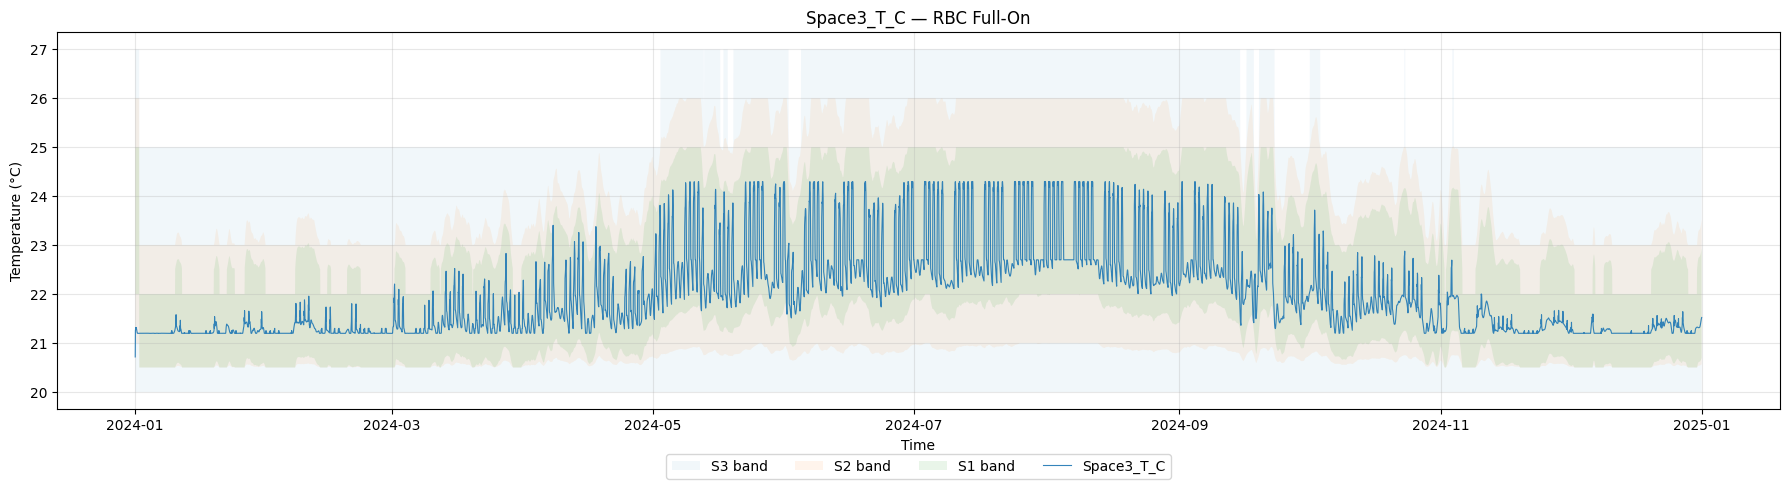

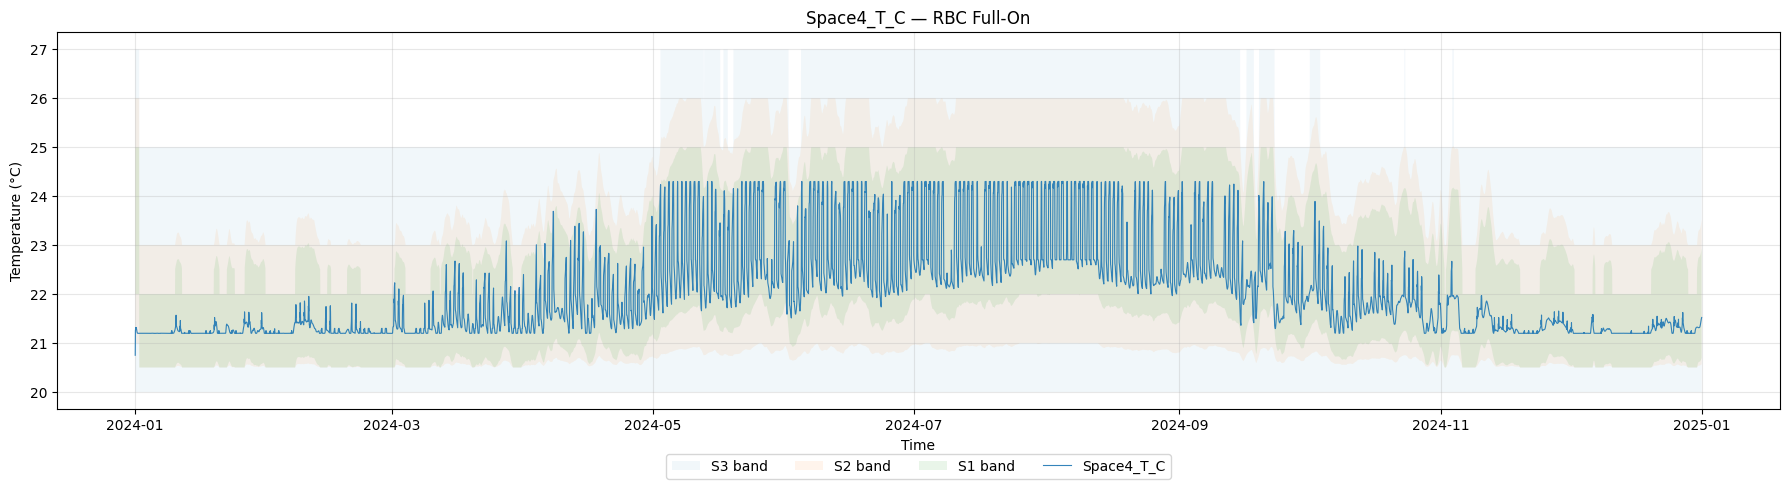

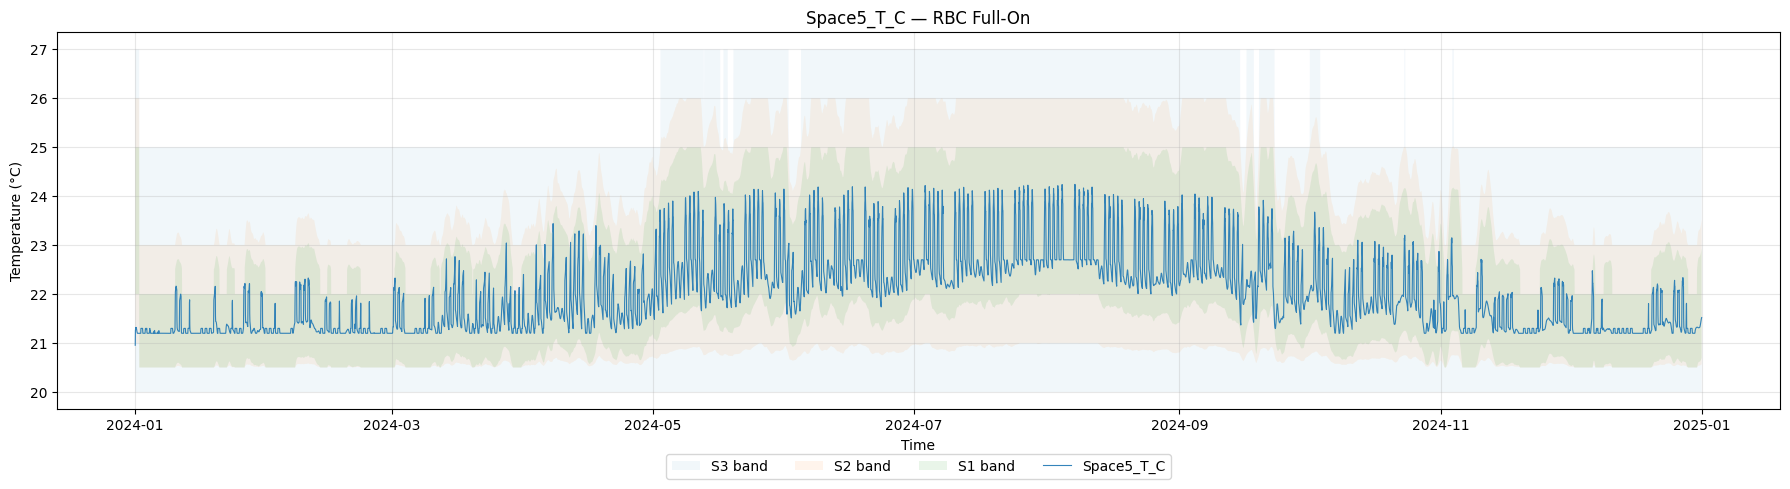

In [283]:
# ── Per-space temperature plots with class bands ─────────────────────────────

lower_S1, upper_S1, lower_S2, upper_S2, lower_S3, upper_S3 = compute_temperature_limits(df)
x = pd.to_datetime(df['Time'])

for i in range(1, 6):
    col = f'Space{i}_T_C'
    fig, ax = plt.subplots(figsize=(18, 5))

    ax.fill_between(x, lower_S3, upper_S3, alpha=0.06, label='S3 band')
    ax.fill_between(x, lower_S2, upper_S2, alpha=0.08, label='S2 band')
    ax.fill_between(x, lower_S1, upper_S1, alpha=0.10, label='S1 band')
    ax.plot(x, df[col], linewidth=0.8, alpha=0.9, label=col)

    ax.set_title(f'{col} — {MODEL_NAME}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Temperature (°C)')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.1))
    plt.tight_layout()
    plt.show()

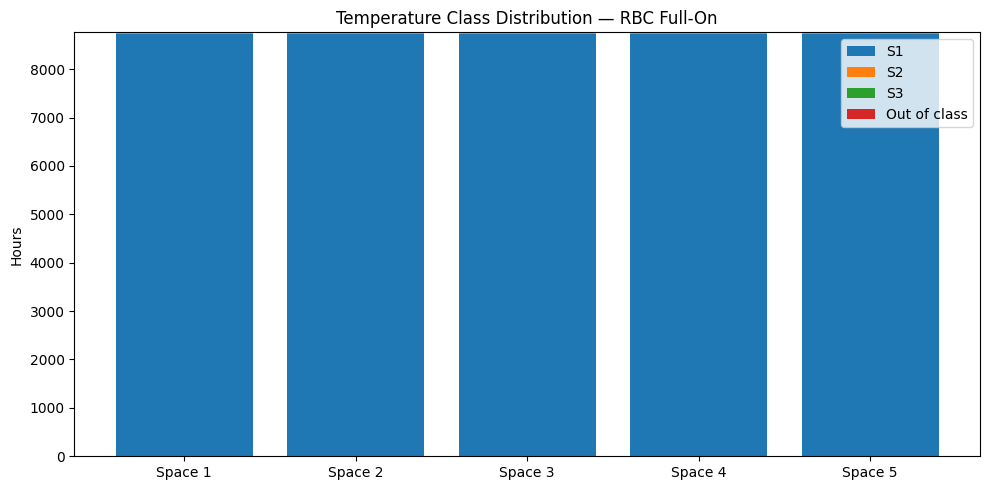

In [284]:
# ── Temperature class distribution stacked bar ───────────────────────────────

spaces = [f'Space{i}_T_C' for i in range(1, 6)]
s1_vals = temp_summary.loc[spaces, 'S1_h']
s2_vals = temp_summary.loc[spaces, 'S2_h']
s3_vals = temp_summary.loc[spaces, 'S3_h']
out_vals = temp_summary.loc[spaces, 'out_h']

labels = [f'Space {i}' for i in range(1, 6)]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x, s1_vals, label='S1')
ax.bar(x, s2_vals, bottom=s1_vals, label='S2')
ax.bar(x, s3_vals, bottom=s1_vals + s2_vals, label='S3')
ax.bar(x, out_vals, bottom=s1_vals + s2_vals + s3_vals, label='Out of class')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Hours')
ax.set_title(f'Temperature Class Distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.show()

## Supply Air

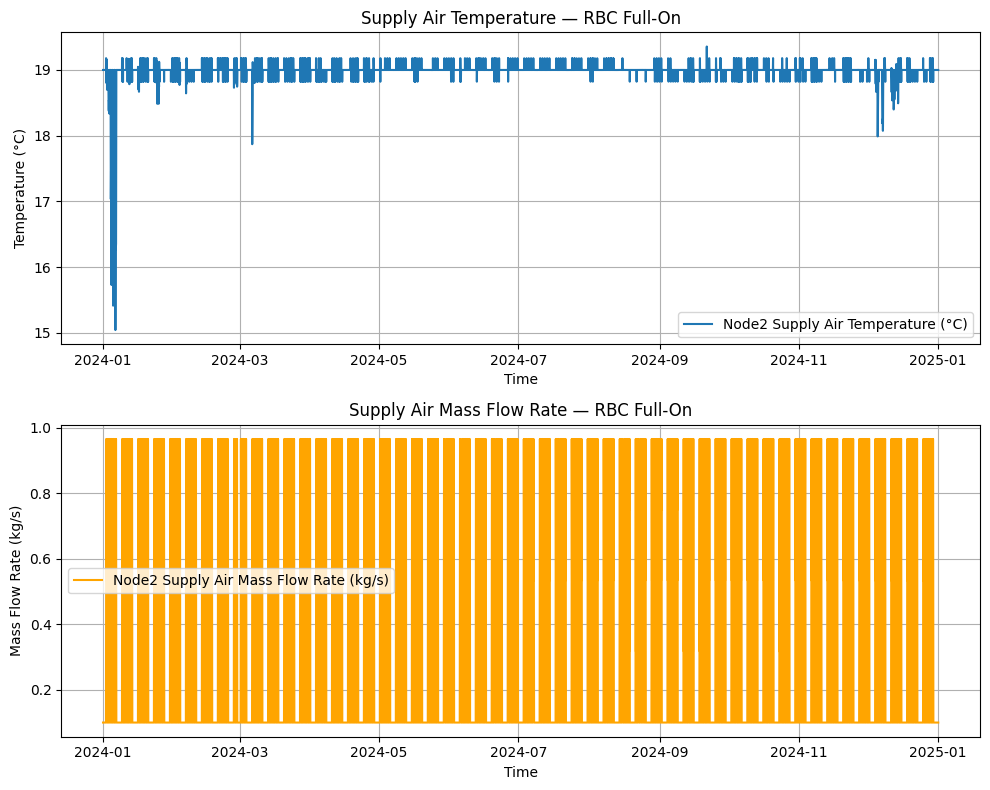

In [285]:
# ── Supply air temperature & flow ────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(df['Time'], df['Node2_T_C'], label='Node2 Supply Air Temperature (°C)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'Supply Air Temperature — {MODEL_NAME}')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df['Time'], df['Node2_Mdot_kg/s'], label='Node2 Supply Air Mass Flow Rate (kg/s)', color='orange')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Mass Flow Rate (kg/s)')
axes[1].set_title(f'Supply Air Mass Flow Rate — {MODEL_NAME}')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

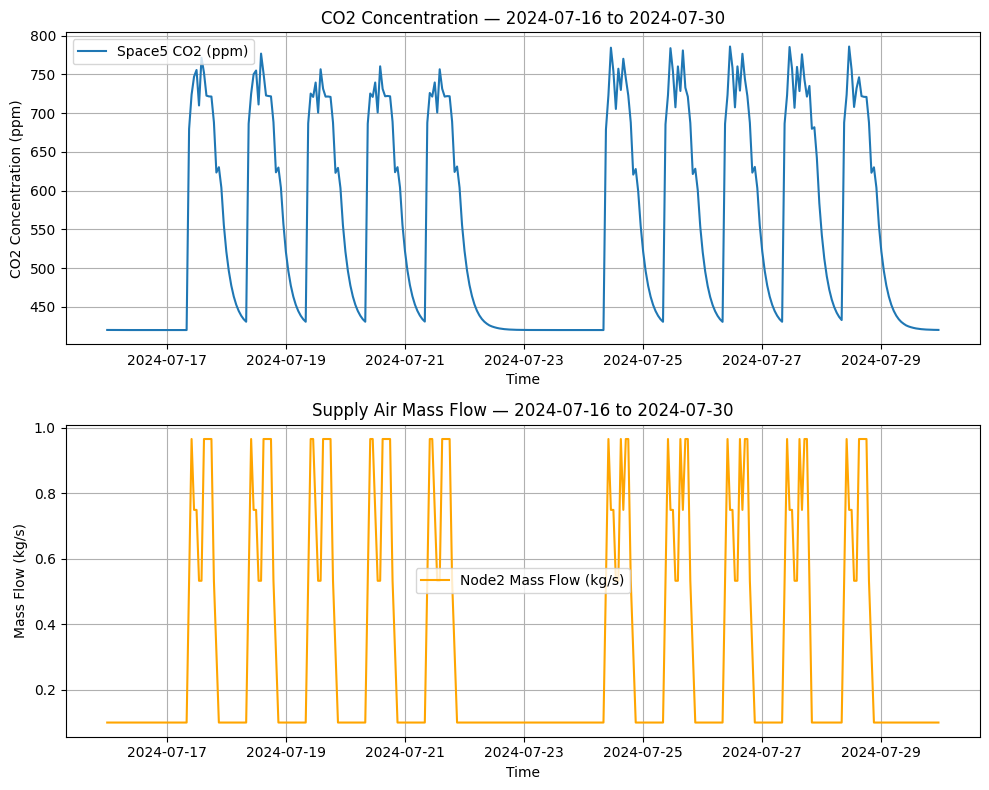

In [286]:
# ── CO2 & supply air flow — 2-week detail ────────────────────────────────────

day_mask = (df['Time'] >= '2024-07-16') & (df['Time'] < '2024-07-30')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(df.loc[day_mask, 'Time'], df.loc[day_mask, 'Space5_CO2_ppm'], label='Space5 CO2 (ppm)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('CO2 Concentration (ppm)')
axes[0].set_title('CO2 Concentration — 2024-07-16 to 2024-07-30')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df.loc[day_mask, 'Time'], df.loc[day_mask, 'Node2_Mdot_kg/s'], label='Node2 Mass Flow (kg/s)', color='orange')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Mass Flow (kg/s)')
axes[1].set_title('Supply Air Mass Flow — 2024-07-16 to 2024-07-30')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Total Cost (Energy + Penalties)

In [287]:
# ── CO2 penalty breakdown ─────────────────────────────────────────────────────

co2_pen = compute_co2_penalty(df)
print(f'CO2 penalty breakdown — {MODEL_NAME}:')
print(f'  Penalties: p1={CO2_P1} €/h (>770 ppm), p2={CO2_P2} €/h (>970 ppm), p3={CO2_P3} €/h (>1220 ppm)')
print()
print(co2_pen)
print(f'\nTotal CO2 penalty: {co2_pen["penalty_eur"].sum():.2f} €')

CO2 penalty breakdown — RBC Full-On:
  Penalties: p1=2 €/h (>770 ppm), p2=10 €/h (>970 ppm), p3=50 €/h (>1220 ppm)

        h_above_S1  h_above_S2  h_above_S3  penalty_eur
space                                                  
Space1          53           0           0          106
Space2           0           0           0            0
Space3          61           0           0          122
Space4          64           0           0          128
Space5          68           0           0          136

Total CO2 penalty: 492.00 €


In [288]:
# ── Temperature penalty breakdown ─────────────────────────────────────────────

temp_pen = compute_temperature_penalty(df)
print(f'Temperature penalty breakdown — {MODEL_NAME}:')
print(f'  outside S1={TEMP_P1} €/h, outside S2={TEMP_P2} €/h, outside S3={TEMP_P3} €/h')
print()
print(temp_pen)
print(f'\nTotal temperature penalty: {temp_pen["penalty_eur"].sum():.2f} €')

Temperature penalty breakdown — RBC Full-On:
  outside S1=1 €/h, outside S2=5 €/h, outside S3=25 €/h

       achieved_class  h_outside_S1  h_outside_S2  h_outside_S3       S1_%  \
space                                                                        
Space1             S1            40             1             0  99.531963   
Space2             S1            29             1             0  99.657534   
Space3             S1            27             1             0  99.680365   
Space4             S1            40             1             0  99.531963   
Space5             S1            43             1             0  99.497717   

        penalty_eur  
space                
Space1           45  
Space2           34  
Space3           32  
Space4           45  
Space5           48  

Total temperature penalty: 204.00 €


╔══════════════════════════════════════════╗
║  Total Cost Summary — RBC Full-On        ║
╠══════════════════════════════════════════╣
║  Energy cost:             7942.65 €    ║
║  CO2 penalty:              492.00 €    ║
║  Temperature penalty:      204.00 €    ║
╠══════════════════════════════════════════╣
║  TOTAL:                   8638.65 €    ║
╚══════════════════════════════════════════╝


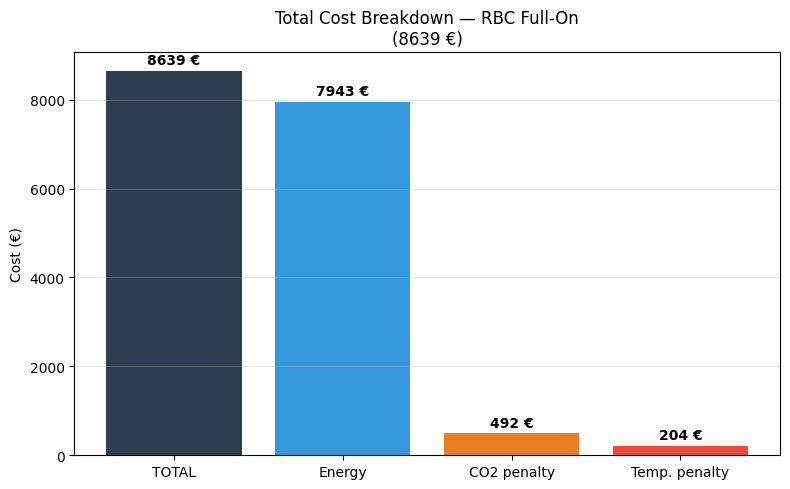

In [289]:
# ── Total cost summary ────────────────────────────────────────────────────────

costs = compute_total_cost(df)

print(f'╔══════════════════════════════════════════╗')
print(f'║  Total Cost Summary — {MODEL_NAME:<18s} ║')
print(f'╠══════════════════════════════════════════╣')
print(f'║  Energy cost:        {costs["energy_cost_eur"]:>12.2f} €    ║')
print(f'║  CO2 penalty:        {costs["co2_penalty_eur"]:>12.2f} €    ║')
print(f'║  Temperature penalty:{costs["temp_penalty_eur"]:>12.2f} €    ║')
print(f'╠══════════════════════════════════════════╣')
print(f'║  TOTAL:              {costs["total_cost_eur"]:>12.2f} €    ║')
print(f'╚══════════════════════════════════════════╝')

# Bar chart — total first, then breakdown
labels = ['TOTAL', 'Energy', 'CO2 penalty', 'Temp. penalty']
values = [costs['total_cost_eur'], costs['energy_cost_eur'], costs['co2_penalty_eur'], costs['temp_penalty_eur']]
colors = ['#2c3e50', '#3498db', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
            f'{val:.0f} €', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Cost (€)')
ax.set_title(f'Total Cost Breakdown — {MODEL_NAME}\n({costs["total_cost_eur"]:.0f} €)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()